In [1]:
import numpy as np
import pandas as pd

# импорт из пакета pmdarima
from sktime.forecasting.arima import AutoARIMA

from sktime.forecasting.arima import StatsModelsARIMA as ARIMA

from sktime.utils.plotting import plot_series
# временной горизонт для прогнозирования
from sktime.forecasting.base import ForecastingHorizon

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

In [2]:
trade = pd.DataFrame()
for i in range (2017, 2026):
    trade_year = pd.read_csv(f'allof{i}.csv')
    trade = pd.concat([trade, trade_year])
trade

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
C,M,20170101,2017,1,201701,699,IND,India,M,Import,...,True,0,False,3.916244e+08,0.000000e+00,3.916244e+08,4,False,True,NaN
C,M,20170101,2017,1,201701,699,IND,India,X,Export,...,True,0,False,0.000000e+00,1.431301e+08,1.431301e+08,4,False,True,NaN
C,M,20170201,2017,2,201702,699,IND,India,M,Import,...,True,0,False,5.561559e+08,0.000000e+00,5.561559e+08,4,False,True,NaN
C,M,20170201,2017,2,201702,699,IND,India,X,Export,...,True,0,False,0.000000e+00,1.731809e+08,1.731809e+08,4,False,True,NaN
C,M,20170301,2017,3,201703,699,IND,India,M,Import,...,True,0,False,8.171612e+08,0.000000e+00,8.171612e+08,4,False,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C,M,20250801,2025,8,202508,699,IND,India,X,Export,...,True,0,False,NaN,3.761128e+08,3.761128e+08,4,False,True,NaN
C,M,20250901,2025,9,202509,699,IND,India,M,Import,...,False,0,False,5.077645e+09,NaN,5.077645e+09,0,False,True,NaN
C,M,20250901,2025,9,202509,699,IND,India,X,Export,...,True,0,False,NaN,4.051215e+08,4.051215e+08,4,False,True,NaN
C,M,20251001,2025,10,202510,699,IND,India,M,Import,...,True,0,False,5.172121e+09,NaN,5.172121e+09,4,False,True,NaN


In [3]:
trade['date'] = pd.to_datetime(trade['refMonth'].astype(str), format='%Y%m')

In [4]:
trade

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate,date
C,M,20170101,2017,1,201701,699,IND,India,M,Import,...,0,False,3.916244e+08,0.000000e+00,3.916244e+08,4,False,True,NaN,2017-01-01
C,M,20170101,2017,1,201701,699,IND,India,X,Export,...,0,False,0.000000e+00,1.431301e+08,1.431301e+08,4,False,True,NaN,2017-01-01
C,M,20170201,2017,2,201702,699,IND,India,M,Import,...,0,False,5.561559e+08,0.000000e+00,5.561559e+08,4,False,True,NaN,2017-02-01
C,M,20170201,2017,2,201702,699,IND,India,X,Export,...,0,False,0.000000e+00,1.731809e+08,1.731809e+08,4,False,True,NaN,2017-02-01
C,M,20170301,2017,3,201703,699,IND,India,M,Import,...,0,False,8.171612e+08,0.000000e+00,8.171612e+08,4,False,True,NaN,2017-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C,M,20250801,2025,8,202508,699,IND,India,X,Export,...,0,False,NaN,3.761128e+08,3.761128e+08,4,False,True,NaN,2025-08-01
C,M,20250901,2025,9,202509,699,IND,India,M,Import,...,0,False,5.077645e+09,NaN,5.077645e+09,0,False,True,NaN,2025-09-01
C,M,20250901,2025,9,202509,699,IND,India,X,Export,...,0,False,NaN,4.051215e+08,4.051215e+08,4,False,True,NaN,2025-09-01
C,M,20251001,2025,10,202510,699,IND,India,M,Import,...,0,False,5.172121e+09,NaN,5.172121e+09,4,False,True,NaN,2025-10-01


In [5]:
trade_mini = trade[['date', 'reporterDesc', 'fobvalue', 'cifvalue']]
trade_mini

,date,reporterDesc,fobvalue,cifvalue
C,2017-01-01,M,3.916244e+08,0.000000e+00
C,2017-01-01,X,1.431301e+08,1.431301e+08
C,2017-02-01,M,5.561559e+08,0.000000e+00
C,2017-02-01,X,1.731809e+08,1.731809e+08
C,2017-03-01,M,8.171612e+08,0.000000e+00
...,...,...,...,...
C,2025-08-01,X,3.761128e+08,3.761128e+08
C,2025-09-01,M,5.077645e+09,NaN
C,2025-09-01,X,4.051215e+08,4.051215e+08
C,2025-10-01,M,5.172121e+09,NaN


In [6]:
rustoind = trade_mini[trade_mini['reporterDesc'] == 'M']
indtorus = trade_mini[trade_mini['reporterDesc'] == 'X']
rustoind = rustoind[['date', 'fobvalue']]
indtorus = indtorus[['date', 'cifvalue']]

In [7]:
rustoind = rustoind.set_index('date')
rustoind

,fobvalue
date,
2017-01-01,3.916244e+08
2017-02-01,5.561559e+08
2017-03-01,8.171612e+08
2017-04-01,7.133012e+08
2017-05-01,8.691990e+08
...,...
2025-06-01,5.251886e+09
2025-07-01,5.164164e+09
2025-08-01,5.098342e+09


In [8]:
indtorus = indtorus.set_index('date')
indtorus

,cifvalue
date,
2017-01-01,1.431301e+08
2017-02-01,1.731809e+08
2017-03-01,2.157498e+08
2017-04-01,1.924696e+08
2017-05-01,1.683013e+08
...,...
2025-06-01,3.160157e+08
2025-07-01,4.022487e+08
2025-08-01,3.761128e+08


In [9]:
compare = pd.merge(rustoind, indtorus, on = 'date')
compare.rename(columns={'fobvalue':'rustoind','cifvalue':'indtorus'}, inplace=True)
compare['rustoind'] = compare['rustoind']/1000000000
compare['indtorus'] = compare['indtorus']/1000000000

In [10]:
compare

,rustoind,indtorus
date,,
2017-01-01,0.391624,0.143130
2017-02-01,0.556156,0.173181
2017-03-01,0.817161,0.215750
2017-04-01,0.713301,0.192470
2017-05-01,0.869199,0.168301
...,...,...
2025-06-01,5.251886,0.316016
2025-07-01,5.164164,0.402249
2025-08-01,5.098342,0.376113


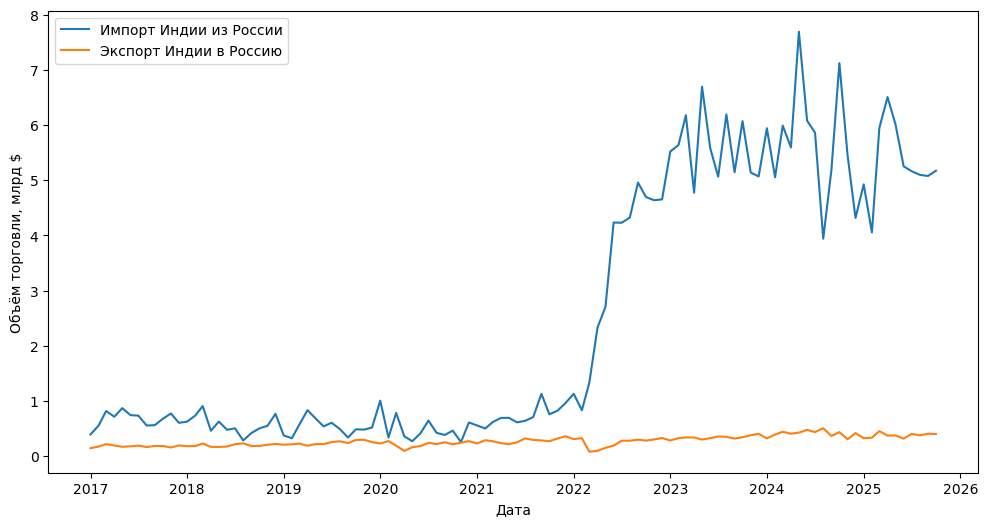

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(compare['rustoind'], label='Импорт Индии из России')
plt.plot(compare['indtorus'], label='Экспорт Индии в Россию')
plt.xlabel('Дата')
plt.ylabel('Объём торговли, млрд $')
plt.legend()

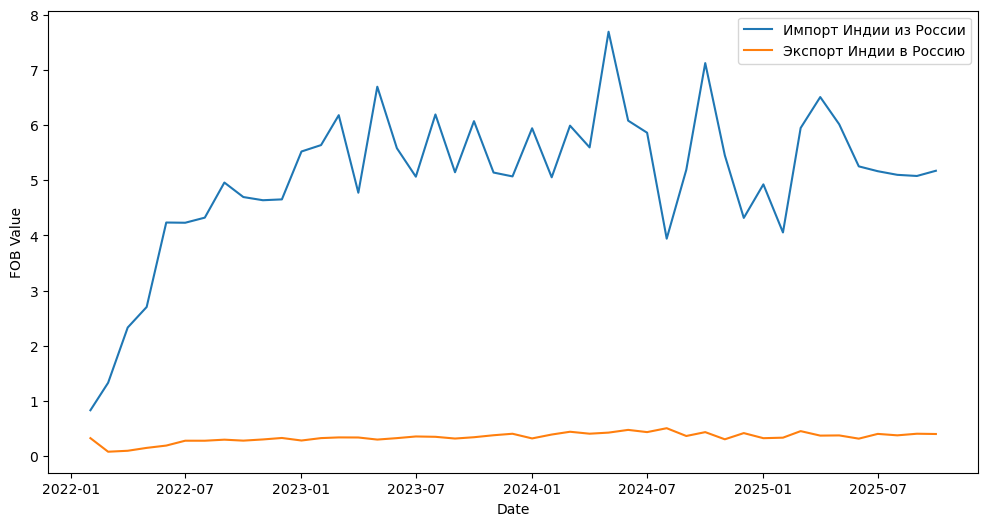

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(compare['rustoind'].tail(45), label='Импорт Индии из России')
plt.plot(compare['indtorus'].tail(45), label='Экспорт Индии в Россию')
plt.xlabel('Date')
plt.ylabel('FOB Value')
plt.legend()

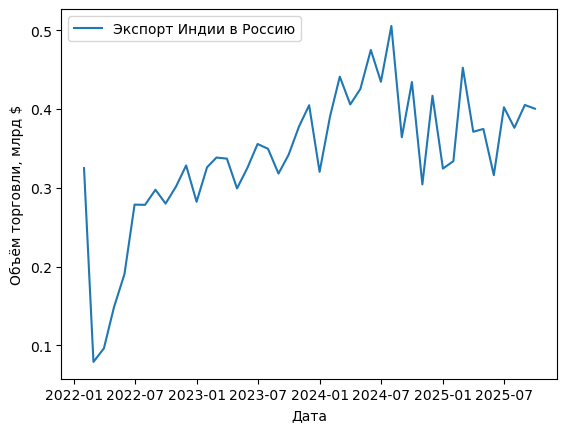

In [13]:
plt.plot(compare['indtorus'].tail(45), label='Экспорт Индии в Россию')
plt.xlabel('Дата')
plt.ylabel('Объём торговли, млрд $')
plt.legend()

In [14]:
rustrade = pd.DataFrame()
for i in range (2017, 2022):
    rustrade_year = pd.read_csv(f'rusallof{i}.csv')
    rustrade = pd.concat([rustrade, rustrade_year])
rustrade['date'] = pd.to_datetime(rustrade['refMonth'].astype(str), format='%Y%m')
rustrade_mini = rustrade[['date', 'reporterDesc', 'fobvalue', 'cifvalue']]
rustoind2 = rustrade_mini[rustrade_mini['reporterDesc'] == 'X']
indtorus2 = rustrade_mini[rustrade_mini['reporterDesc'] == 'M']
rustoind2 = rustoind2[['date', 'cifvalue']]
indtorus2 = indtorus2[['date', 'fobvalue']]
rustoind2 = rustoind2.set_index('date')
indotrus2 = indtorus2.set_index('date')
ruscompare = pd.merge(rustoind2, indtorus2, on = 'date')
ruscompare.rename(columns={'fobvalue':'indtorus','cifvalue':'rustoind'}, inplace=True)
ruscompare['rustoind'] = ruscompare['rustoind']/1000000000
ruscompare['indtorus'] = ruscompare['indtorus']/1000000000
ruscompare = ruscompare.set_index('date')
ruscompare

,rustoind,indtorus
date,,
2017-01-01,0.247282,0.199835
2017-02-01,0.367006,0.227691
2017-03-01,0.775110,0.280322
2017-04-01,0.274255,0.270608
2017-05-01,0.690336,0.289179
2017-06-01,0.628688,0.269365
2017-07-01,0.665619,0.246682
2017-08-01,0.653340,0.260986
2017-09-01,0.518629,0.255876


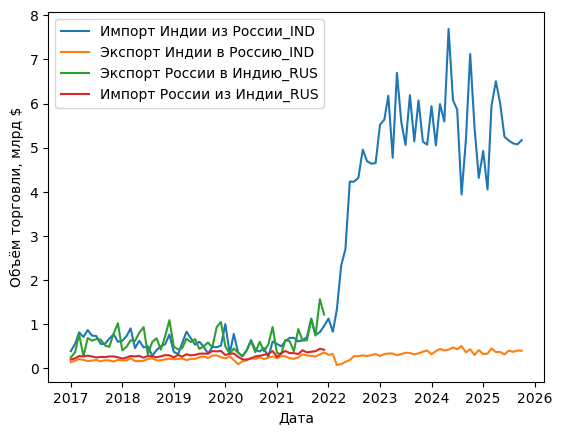

In [15]:
plt.plot(compare['rustoind'], label='Импорт Индии из России_IND')
plt.plot(compare['indtorus'], label='Экспорт Индии в Россию_IND')
plt.plot(ruscompare['rustoind'], label='Экспорт России в Индию_RUS')
plt.plot(ruscompare['indtorus'], label='Импорт России из Индии_RUS')
plt.xlabel('Дата')
plt.ylabel('Объём торговли, млрд $')
plt.legend()

In [16]:
compare.diff()

,rustoind,indtorus
date,,
2017-01-01,NaN,NaN
2017-02-01,0.164531,0.030051
2017-03-01,0.261005,0.042569
2017-04-01,-0.103860,-0.023280
2017-05-01,0.155898,-0.024168
...,...,...
2025-06-01,-0.762868,-0.058668
2025-07-01,-0.087721,0.086233
2025-08-01,-0.065822,-0.026136


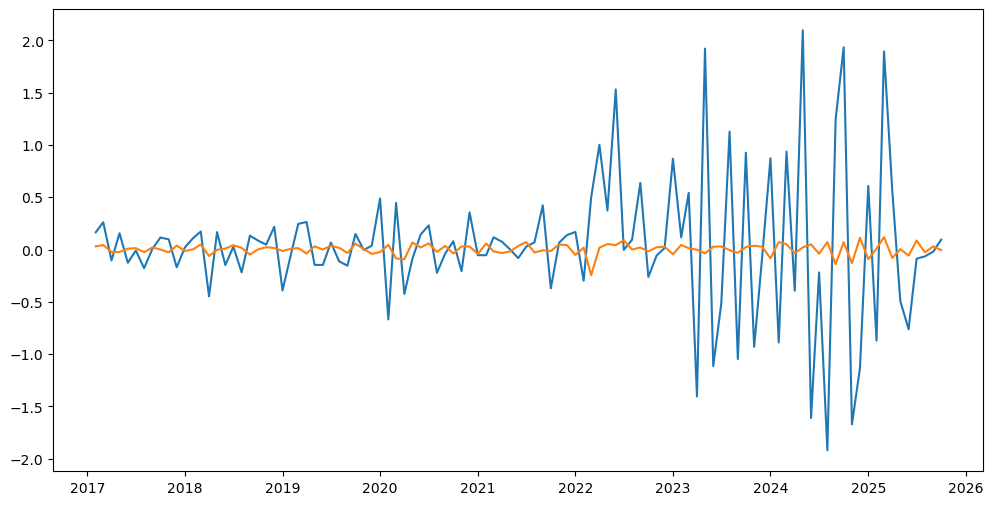

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(compare.diff()['rustoind'], label='Импорт Индии из России_IND')
plt.plot(compare.diff()['indtorus'], label='Экспорт Индии в Россию_IND')

In [18]:
from statsmodels.tsa.api import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Text(0.5, 1.0, 'Автокорреляция интегрированного ряда значений импорта из России')

<Figure size 600x600 with 0 Axes>

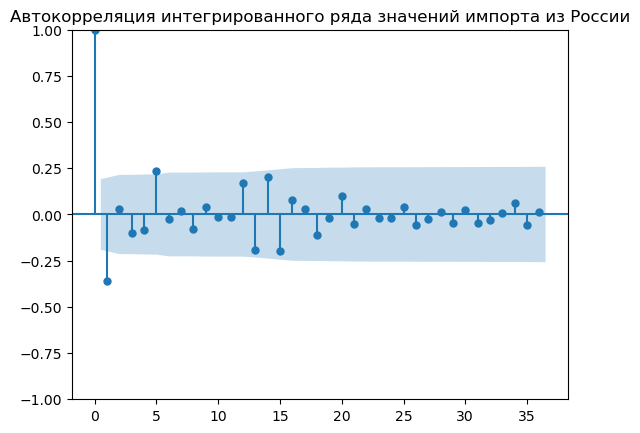

In [19]:
plt.figure(figsize=(6, 6))
plot_acf(compare['rustoind'].diff().dropna(), alpha=0.05, zero=True, lags=36)
plt.title('Автокорреляция интегрированного ряда значений импорта из России')

Text(0.5, 1.0, 'Автокорреляция интегрированного ряда значений экспорта в Россию')

<Figure size 600x600 with 0 Axes>

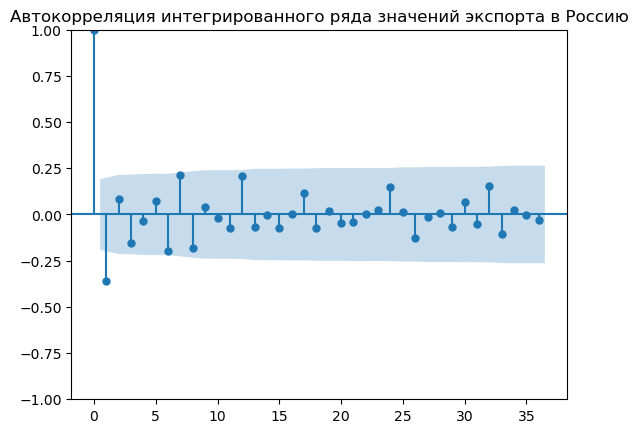

In [20]:
plt.figure(figsize=(6, 6))
plot_acf(compare['indtorus'].diff().dropna(), lags=36, alpha=0.05, zero=True)
plt.title('Автокорреляция интегрированного ряда значений экспорта в Россию')

In [21]:
compare['rustoind_sma12'] = compare['rustoind'].rolling(window=12).mean()
compare

,rustoind,indtorus,rustoind_sma12
date,,,
2017-01-01,0.391624,0.143130,NaN
2017-02-01,0.556156,0.173181,NaN
2017-03-01,0.817161,0.215750,NaN
2017-04-01,0.713301,0.192470,NaN
2017-05-01,0.869199,0.168301,NaN
...,...,...,...
2025-06-01,5.251886,0.316016,5.382312
2025-07-01,5.164164,0.402249,5.324202
2025-08-01,5.098342,0.376113,5.420644


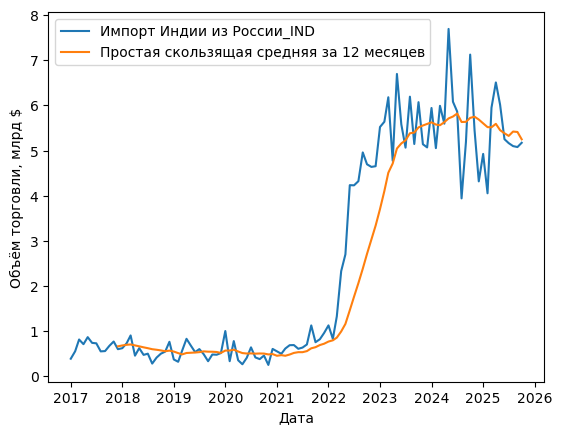

In [22]:
plt.plot(compare['rustoind'], label='Импорт Индии из России_IND')
plt.plot(compare['rustoind_sma12'], label='Простая скользящая средняя за 12 месяцев')
plt.xlabel('Дата')
plt.ylabel('Объём торговли, млрд $')
plt.legend()

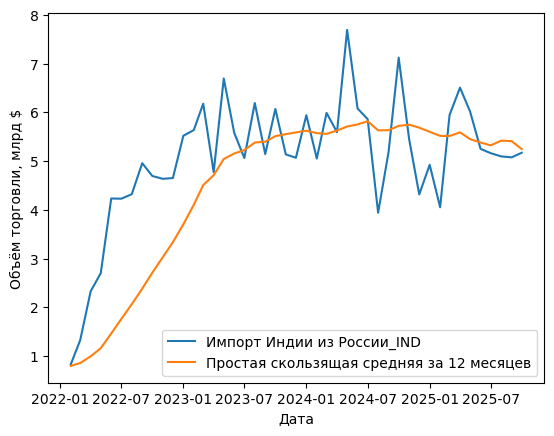

In [23]:
plt.plot(compare['rustoind'].tail(45), label='Импорт Индии из России_IND')
plt.plot(compare['rustoind_sma12'].tail(45), label='Простая скользящая средняя за 12 месяцев')
plt.xlabel('Дата')
plt.ylabel('Объём торговли, млрд $')
plt.legend()

In [24]:
max_sma12 = compare['rustoind_sma12'].idxmax()
row_with_max = compare.loc[max_sma12]
row_with_max

rustoind          5.861486
indtorus          0.434553
rustoind_sma12    5.819528
Name: 2024-07-01 00:00:00, dtype: float64

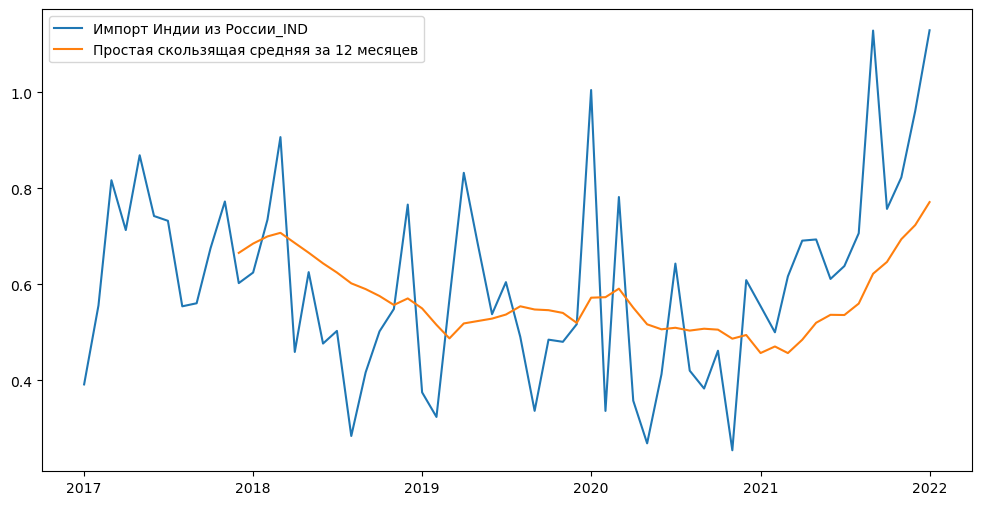

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(compare['rustoind'].head(61), label='Импорт Индии из России_IND')
plt.plot(compare['rustoind_sma12'].head(61), label='Простая скользящая средняя за 12 месяцев')
plt.legend()

In [26]:
min_sma12 = compare['rustoind_sma12'].idxmin()
row_with_min = compare.loc[min_sma12]
row_with_min

rustoind          0.616782
indtorus          0.268758
rustoind_sma12    0.456911
Name: 2021-03-01 00:00:00, dtype: float64

In [27]:
from statsmodels.tsa.api import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [28]:
compare['rustoind'].max()

7.692531659479

In [29]:
compare['rustoind'].min()

0.25435498706299997

In [30]:
compare['indtorus'].max()

0.5054128551970001

In [31]:
compare['indtorus'].min()

0.079092548322

In [32]:
compare['indtorus_sma12'] = compare['indtorus'].rolling(window=12).mean()

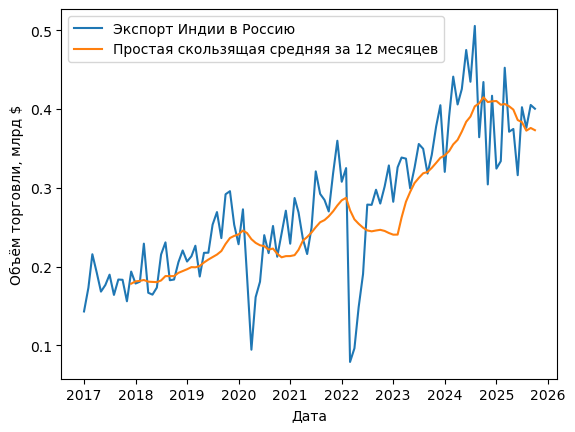

In [33]:
plt.plot(compare['indtorus'], label='Экспорт Индии в Россию')
plt.plot(compare['indtorus_sma12'], label='Простая скользящая средняя за 12 месяцев')
plt.xlabel('Дата')
plt.ylabel('Объём торговли, млрд $')
plt.legend()

In [34]:
max_sma12_ind = compare['indtorus_sma12'].idxmax()
row_with_max_ind = compare.loc[max_sma12_ind]
row_with_max_ind

rustoind          7.124071
indtorus          0.434219
rustoind_sma12    5.723343
indtorus_sma12    0.414920
Name: 2024-10-01 00:00:00, dtype: float64

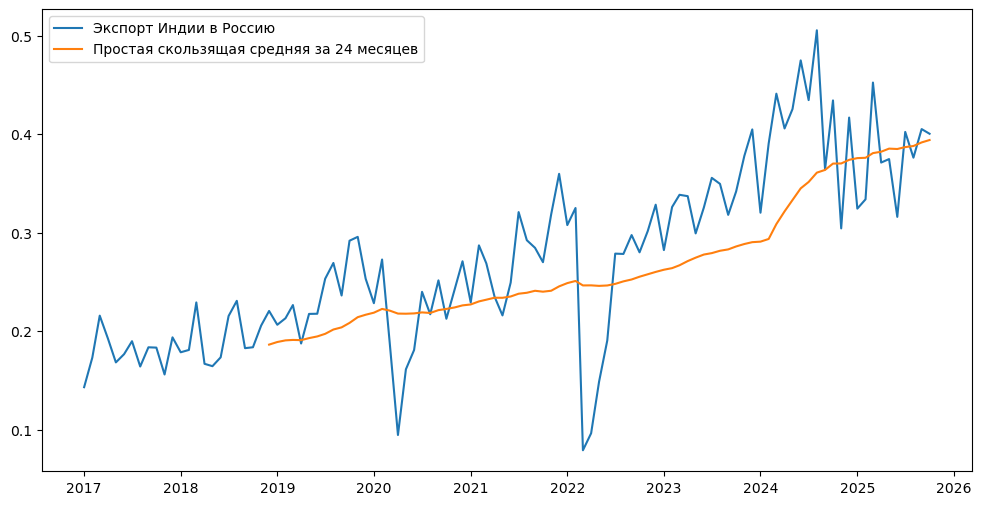

In [35]:
compare['indtorus_sma24'] = compare['indtorus'].rolling(window=24).mean()
compare['rustoind_sma24'] = compare['rustoind'].rolling(window=24).mean()
plt.figure(figsize=(12, 6))
plt.plot(compare['indtorus'], label='Экспорт Индии в Россию')
plt.plot(compare['indtorus_sma24'], label='Простая скользящая средняя за 24 месяцев')
plt.legend()

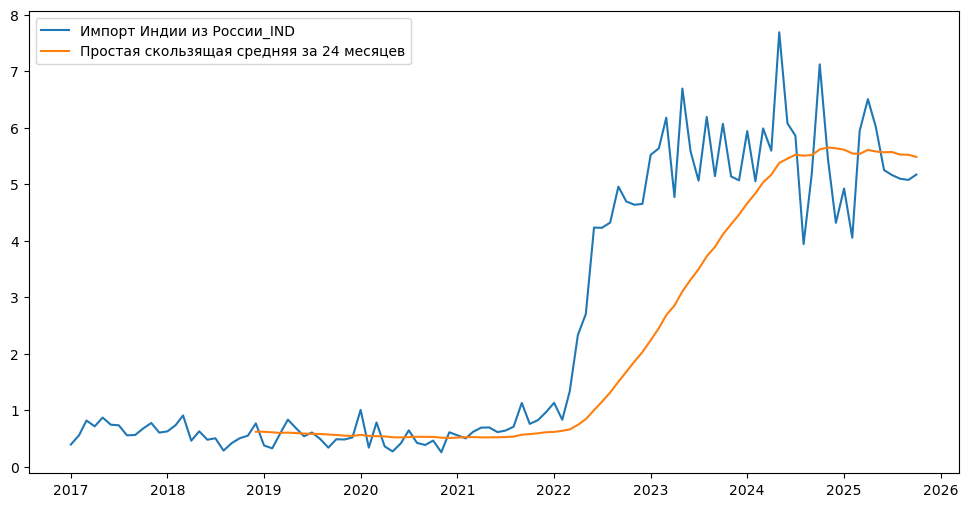

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(compare['rustoind'], label='Импорт Индии из России_IND')
plt.plot(compare['rustoind_sma24'], label='Простая скользящая средняя за 24 месяцев')
plt.legend()

In [37]:
from statsmodels.tsa.api import adfuller, kpss, range_unit_root_test

In [38]:
compare_fixed = compare.copy()
compare_fixed.index = compare_fixed.index.to_period('M').to_timestamp('M')
compare_fixed = compare_fixed.asfreq('ME')
compare_fixed

,rustoind,indtorus,rustoind_sma12,indtorus_sma12,indtorus_sma24,rustoind_sma24
date,,,,,,
2017-01-31,0.391624,0.143130,NaN,NaN,NaN,NaN
2017-02-28,0.556156,0.173181,NaN,NaN,NaN,NaN
2017-03-31,0.817161,0.215750,NaN,NaN,NaN,NaN
2017-04-30,0.713301,0.192470,NaN,NaN,NaN,NaN
2017-05-31,0.869199,0.168301,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-06-30,5.251886,0.316016,5.382312,0.385991,0.384898,5.567716
2025-07-31,5.164164,0.402249,5.324202,0.383299,0.386841,5.571865
2025-08-31,5.098342,0.376113,5.420644,0.372524,0.387950,5.526269


In [39]:
adf_stat1, pval1, usedlag1, nobs1, critical_values1, BIC1 = adfuller(compare_fixed['rustoind'], regression='ct', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat1, pval1, critical_values1

(np.float64(-2.107827843948736),
 np.float64(0.5417105797176878),
 {'1%': np.float64(-4.048566630170403),
  '5%': np.float64(-3.4535811509302454),
  '10%': np.float64(-3.1522943225136553)})

p-value > 0.05 Ряд нестационарен. Нужно дифференцирование

In [40]:
adf_stat1, pval1, usedlag1, nobs1, critical_values1, BIC1 = adfuller(compare_fixed['rustoind'].diff().dropna(), regression='c', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat1, pval1, critical_values1

(np.float64(-14.696422305370048),
 np.float64(2.99341700288342e-27),
 {'1%': np.float64(-3.4948504603223145),
  '5%': np.float64(-2.889758398668639),
  '10%': np.float64(-2.5818220155325444)})

p-value < 0.05 Ряд стационарен.

I = 1

In [41]:
kpss_stat1, p_value1, lags1, crit1 = kpss(compare_fixed['rustoind'], regression='ct')
# тестовая статистика, её p-значение и критические значения
kpss_stat1, p_value1, crit1

C:\Temp\ipykernel_2612\1107410024.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat1, p_value1, lags1, crit1 = kpss(compare_fixed['rustoind'], regression='ct')


(np.float64(0.27573883483820383),
 np.float64(0.01),
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

P-value < 0.05 Ряд нестационарен. Нужно дифференцирование

In [42]:
kpss_stat1, p_value1, lags1, crit1 = kpss(compare_fixed['rustoind'].diff().dropna(), regression='c')
# тестовая статистика, её p-значение и критические значения
kpss_stat1, p_value1, crit1

C:\Temp\ipykernel_2612\4138588623.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat1, p_value1, lags1, crit1 = kpss(compare_fixed['rustoind'].diff().dropna(), regression='c')


(np.float64(0.11348614180812819),
 np.float64(0.1),
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

P-value > 0.05. Ряд стационарен.

I = 1

In [43]:
from statsmodels.tsa.stattools import arma_order_select_ic

In [44]:
# Используем информационные критерии AIC, AICC, BIC, HQIC
res1 = arma_order_select_ic(compare_fixed['rustoind'].diff().dropna(), max_ar=4, max_ma=4, ic=['aic', 'aicc', 'bic', 'hqic'], trend='c')

In [45]:
res1.aic

,0,1,2,3,4
0,219.404279,203.635654,205.512893,207.071901,207.599764
1,207.106496,205.495998,207.489757,208.889862,207.048175
2,207.721082,207.461749,209.332576,203.473528,206.462097
3,207.418282,208.063153,205.333550,205.408017,205.460779
4,204.856721,205.953166,206.585797,208.256599,209.006706


In [46]:
# оптимальный порядок по AIC
res1.aic_min_order

(np.int64(2), np.int64(3))

In [47]:
res1.aicc

,0,1,2,3,4
0,219.521926,203.873278,205.912893,207.677962,208.456907
1,207.344120,205.895998,208.095818,209.747005,208.202814
2,208.121082,208.067810,210.189719,204.628168,207.962097
3,208.024343,208.920296,206.488189,206.908017,207.355516
4,205.713863,207.107805,208.085797,210.151336,211.347132


In [48]:
# оптимальный порядок по AICc
res1.aicc_min_order

(np.int64(0), np.int64(1))

In [49]:
res1.bic

,0,1,2,3,4
0,224.712199,211.597535,216.128735,220.341703,223.523526
1,215.068377,216.111839,220.759559,224.813624,225.625897
2,218.336923,220.731551,225.256338,222.051251,227.693779
3,220.688084,223.986915,223.911272,226.639700,229.346422
4,220.780483,224.530888,227.817480,232.142243,235.546310


In [50]:
# оптимальный порядок по BIC
res1.bic_min_order

(np.int64(0), np.int64(1))

In [51]:
# оптимальный порядок по HQIC
res1.hqic_min_order

(np.int64(0), np.int64(1))

In [52]:
forecaster1 = AutoARIMA(information_criterion='bic', test='adf',  seasonal=False)
forecaster1.fit(compare_fixed['rustoind'])
forecaster1.get_fitted_params() #['order']

{'ma.L1': np.float64(-0.4231808628652336),
 'sigma2': np.float64(0.3900655139174066),
 'order': (0, 1, 1),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(203.32445297401233),
 'aicc': np.float64(203.44210003283587),
 'bic': np.float64(208.63237367432737),
 'hqic': np.float64(205.47532715531065)}

In [53]:
fh = ForecastingHorizon(np.arange(1,27))

y_pred_rustoind = forecaster1.fit_predict(y=compare_fixed['rustoind'], fh=fh)
y_pred_rustoind

D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  r

2025-11-30    5.153908
2025-12-31    5.153908
2026-01-31    5.153908
2026-02-28    5.153908
2026-03-31    5.153908
2026-04-30    5.153908
2026-05-31    5.153908
2026-06-30    5.153908
2026-07-31    5.153908
2026-08-31    5.153908
2026-09-30    5.153908
2026-10-31    5.153908
2026-11-30    5.153908
2026-12-31    5.153908
2027-01-31    5.153908
2027-02-28    5.153908
2027-03-31    5.153908
2027-04-30    5.153908
2027-05-31    5.153908
2027-06-30    5.153908
2027-07-31    5.153908
2027-08-31    5.153908
2027-09-30    5.153908
2027-10-31    5.153908
2027-11-30    5.153908
2027-12-31    5.153908
Freq: ME, Name: rustoind, dtype: float64

In [54]:
forecaster1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  106
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 -99.662
Date:                Sun, 24 May 2026   AIC                            203.324
Time:                        21:54:50   BIC                            208.632
Sample:                    01-31-2017   HQIC                           205.475
                         - 10-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4232      0.069     -6.143      0.000      -0.558      -0.288
sigma2         0.3901      0.034     11.491      0.000       0.324       0.457
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                41.76
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):              34.27   Skew:                             0.47
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [55]:
adf_stat2, pval2, usedlag2, nobs2, critical_values2, BIC2 = adfuller(compare_fixed['indtorus'], regression='ct', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat2, pval2, critical_values2

(np.float64(-5.683146282409999),
 np.float64(9.90843970062169e-06),
 {'1%': np.float64(-4.047684391534392),
  '5%': np.float64(-3.4531621209372636),
  '10%': np.float64(-3.1520501036605117)})

p-value < 0.05 Ряд стационарен.

I = 0

In [56]:
kpss_stat2, p_value2, lags2, crit2 = kpss(compare_fixed['indtorus'], regression='ct')
# тестовая статистика, её p-значение и критические значения
kpss_stat2, p_value2, crit2

(np.float64(0.13121195055920118),
 np.float64(0.07738527674222002),
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

P-value > 0.05. Ряд стационарен.

I = 0

In [57]:
# Используем информационные критерии AIC, AICC, BIC, HQIC
res2 = arma_order_select_ic(compare_fixed['indtorus'], max_ar=4, max_ma=4, ic=['aic', 'aicc', 'bic', 'hqic'], trend='c')

In [58]:
# оптимальный порядок по AIC
res2.aic_min_order

(np.int64(4), np.int64(4))

In [59]:
# оптимальный порядок по AICc
res2.aicc_min_order

(np.int64(4), np.int64(4))

In [60]:
# оптимальный порядок по BIC
res2.bic_min_order

(np.int64(1), np.int64(1))

In [61]:
# оптимальный порядок по HQIC
res2.hqic_min_order

(np.int64(1), np.int64(1))

In [62]:
forecaster2 = AutoARIMA(information_criterion='aic', test='adf', seasonal=False)
forecaster2.fit(compare_fixed['indtorus'])
forecaster2.get_fitted_params() #['order']

{'intercept': np.float64(0.015406047945735168),
 'ar.L1': np.float64(0.9437280881282913),
 'ma.L1': np.float64(-0.3827923282907246),
 'sigma2': np.float64(0.002311799784227454),
 'order': (1, 0, 1),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-333.1178899088533),
 'aicc': np.float64(-332.7218503048929),
 'bic': np.float64(-322.464133532405),
 'hqic': np.float64(-328.7998644770487)}

In [63]:
forecaster2 = AutoARIMA(information_criterion='bic', test='adf', seasonal=False)
forecaster2.fit(compare_fixed['indtorus'])
forecaster2.get_fitted_params() #['order']

{'ar.L1': np.float64(0.9957618357909328),
 'ma.L1': np.float64(-0.4364691605734579),
 'sigma2': np.float64(0.0023584029120097237),
 'order': (1, 0, 1),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-330.6390591496833),
 'aicc': np.float64(-330.40376503203623),
 'bic': np.float64(-322.6487418673471),
 'hqic': np.float64(-327.4005400758299)}

In [64]:
y_pred_indtorus= forecaster2.fit_predict(y=compare_fixed['indtorus'], fh=fh)
y_pred_indtorus

D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  r

2025-11-30    0.393977
2025-12-31    0.392307
2026-01-31    0.390644
2026-02-28    0.388989
2026-03-31    0.387340
2026-04-30    0.385699
2026-05-31    0.384064
2026-06-30    0.382436
2026-07-31    0.380815
2026-08-31    0.379201
2026-09-30    0.377594
2026-10-31    0.375994
2026-11-30    0.374400
2026-12-31    0.372814
2027-01-31    0.371234
2027-02-28    0.369660
2027-03-31    0.368094
2027-04-30    0.366534
2027-05-31    0.364980
2027-06-30    0.363433
2027-07-31    0.361893
2027-08-31    0.360359
2027-09-30    0.358832
2027-10-31    0.357311
2027-11-30    0.355797
2027-12-31    0.354289
Freq: ME, Name: indtorus, dtype: float64

In [65]:
forecaster2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  106
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 168.320
Date:                Sun, 24 May 2026   AIC                           -330.639
Time:                        21:55:11   BIC                           -322.649
Sample:                    01-31-2017   HQIC                          -327.401
                         - 10-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9958      0.007    134.857      0.000       0.981       1.010
ma.L1         -0.4365      0.081     -5.379      0.000      -0.595      -0.277
sigma2         0.0024      0.000     12.412      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):               196.69
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               3.62   Skew:                            -1.57
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

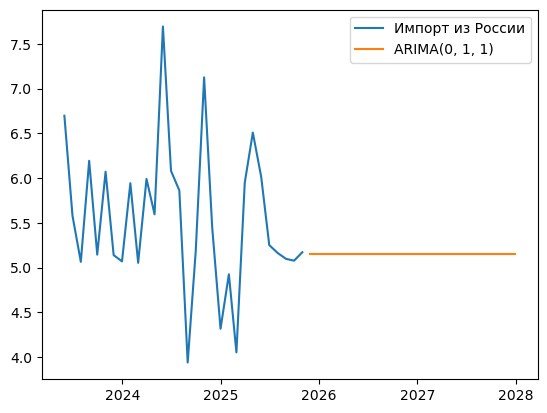

In [66]:
plt.plot(compare_fixed['rustoind'].tail(30), label='Импорт из России')
plt.plot(y_pred_rustoind, label='ARIMA(0, 1, 1)')
plt.legend()
plt.show()

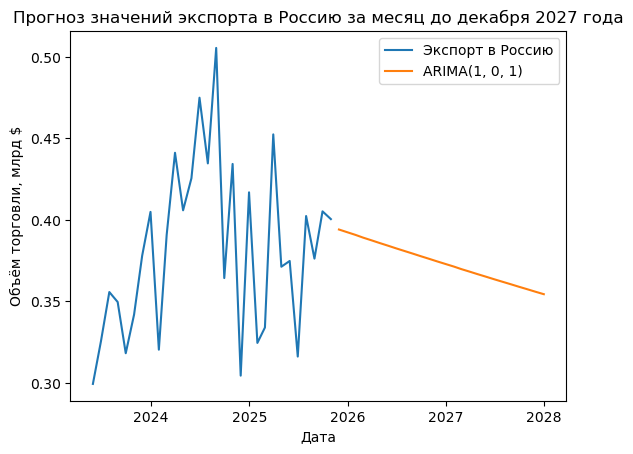

In [87]:
plt.plot(compare_fixed['indtorus'].tail(30), label='Экспорт в Россию')
plt.plot(y_pred_indtorus, label='ARIMA(1, 0, 1)')
plt.xlabel('Дата')
plt.ylabel('Объём торговли, млрд $')
plt.title('Прогноз значений экспорта в Россию за месяц до декабря 2027 года')
plt.legend()
plt.show()

In [68]:
# Модель для прогнозирования, например ARIMA
from sktime.forecasting.arima import ARIMA
# Визуализация временных рядов
from sktime.utils.plotting import plot_series
# Модули для кросс-валидации
from sktime.split import temporal_train_test_split, ExpandingWindowSplitter, SlidingWindowSplitter, SingleWindowSplitter
from sktime.forecasting.model_evaluation import evaluate
from sktime.performance_metrics.forecasting import MeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError # Метрики MSE, MAE, MAPE

In [81]:
cv_strategy = SingleWindowSplitter(fh=fh, window_length=len(compare_fixed)-5)

# инициализируем метрики
metric = [MeanSquaredError(square_root=False), MeanAbsoluteError(), MeanAbsolutePercentageError()]

cv_res = evaluate(forecaster=forecaster1, y=compare_fixed['rustoind'], cv=cv_strategy, strategy="refit", return_data=False, scoring=metric)
cv_res

D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  r

,test_MeanSquaredError,test_MeanAbsoluteError,test_MeanAbsolutePercentageError,fit_time,pred_time,len_train_window,cutoff
0,0.908871,0.762332,0.151027,5.162655,0.05742,80,2023-08-31


In [82]:
forecaster11 = ARIMA(order=(0,1,1), trend='ct')

cv_res = evaluate(forecaster=forecaster11, y=compare_fixed['rustoind'], cv=cv_strategy, strategy="refit", return_data=False, scoring=metric)
cv_res

D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  r

,test_MeanSquaredError,test_MeanAbsoluteError,test_MeanAbsolutePercentageError,fit_time,pred_time,len_train_window,cutoff
0,17.773674,3.625577,0.705066,0.292049,0.04532,80,2023-08-31


In [83]:
cv_res1 = evaluate(forecaster=forecaster2, y=compare_fixed['indtorus'], cv=cv_strategy, strategy="refit", return_data=False, scoring=metric)
cv_res1

D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  r

,test_MeanSquaredError,test_MeanAbsoluteError,test_MeanAbsolutePercentageError,fit_time,pred_time,len_train_window,cutoff
0,0.005934,0.062405,0.149323,2.3658,0.045458,80,2023-08-31


In [72]:
from sktime.forecasting.arch import ARCH
# Модули для кросс-валидации
from sktime.split import temporal_train_test_split, ExpandingWindowSplitter, SlidingWindowSplitter, SingleWindowSplitter
from sktime.performance_metrics.forecasting import MeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError # Метрики MSE, MAE, MAPE
# Поиск оптимальных гиперпараметров по сетке
from sktime.forecasting.model_selection import ForecastingGridSearchCV

In [73]:
# Зададим метод прогнозирования
forecaster_garch = ARCH(mean='AR')

# разбиваем параметры кросс-валидации
cv_strategy1 = ExpandingWindowSplitter(fh=fh, initial_window=70, step_length=5)
param_grid1 = {'lags':[0, 1, 2], 'p': [0, 1, 2], 'o': [0, 1, 2], 'q': [0, 1, 2], 'vol':['GARCH', 'EGARCH'], 'dist':['normal', 't', 'skewt']}

# инициализируем метрику
metric1 = MeanSquaredError(square_root=False)
# metric = MeanAbsoluteError()
# metric = MeanAbsolutePercentageError()
# Grid search
gscv = ForecastingGridSearchCV(forecaster=forecaster_garch, param_grid=param_grid1, cv=cv_strategy1, scoring=metric1)

gscv.fit(compare_fixed['rustoind'])

ForecastingGridSearchCV(cv=ExpandingWindowSplitter(fh=ForecastingHorizon([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26],
      dtype='int64', is_relative=True),
                                                   initial_window=70,
                                                   step_length=5),
                        forecaster=ARCH(mean='AR'),
                        param_grid={'dist': ['normal', 't', 'skewt'],
                                    'lags': [0, 1, 2], 'o': [0, 1, 2],
                                    'p': [0, 1, 2], 'q': [0, 1, 2],
                                    'vol': ['GARCH', 'EGARCH']},
                        scoring=MeanSquaredError())

In [74]:
# Параметры оптимальной модели
gscv.get_fitted_params()['best_forecaster']

ARCH(dist='t', lags=1, mean='AR', o=2, p=0, q=0, vol='EGARCH')

In [75]:
gscv.fit(compare_fixed['indtorus'])

ForecastingGridSearchCV(cv=ExpandingWindowSplitter(fh=ForecastingHorizon([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26],
      dtype='int64', is_relative=True),
                                                   initial_window=70,
                                                   step_length=5),
                        forecaster=ARCH(mean='AR'),
                        param_grid={'dist': ['normal', 't', 'skewt'],
                                    'lags': [0, 1, 2], 'o': [0, 1, 2],
                                    'p': [0, 1, 2], 'q': [0, 1, 2],
                                    'vol': ['GARCH', 'EGARCH']},
                        scoring=MeanSquaredError())

In [76]:
# Параметры оптимальной модели
gscv.get_fitted_params()['best_forecaster']

ARCH(dist='t', lags=2, mean='AR', p=2, q=0, vol='EGARCH')

In [84]:
forecaster_g1 = ARCH(dist='t', lags=1, mean='AR', o=2, p=0, q=0, vol='EGARCH') 

cv_res = evaluate(forecaster=forecaster_g1, y=compare_fixed['rustoind'], cv=cv_strategy, strategy="refit", return_data=False, scoring=metric)
cv_res

D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


,test_MeanSquaredError,test_MeanAbsoluteError,test_MeanAbsolutePercentageError,fit_time,pred_time,len_train_window,cutoff
0,0.81811,0.721246,0.141329,0.245675,0.023434,80,2023-08-31


In [85]:
forecaster_g2 = ARCH(dist='t', lags=2, mean='AR', p=2, q=0, vol='EGARCH') 

cv_res = evaluate(forecaster=forecaster_g2, y=compare_fixed['indtorus'], cv=cv_strategy, strategy="refit", return_data=False, scoring=metric)
cv_res

D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


,test_MeanSquaredError,test_MeanAbsoluteError,test_MeanAbsolutePercentageError,fit_time,pred_time,len_train_window,cutoff
0,0.016564,0.11556,0.283274,0.175715,0.021791,80,2023-08-31


D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
D:\Anaconda\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


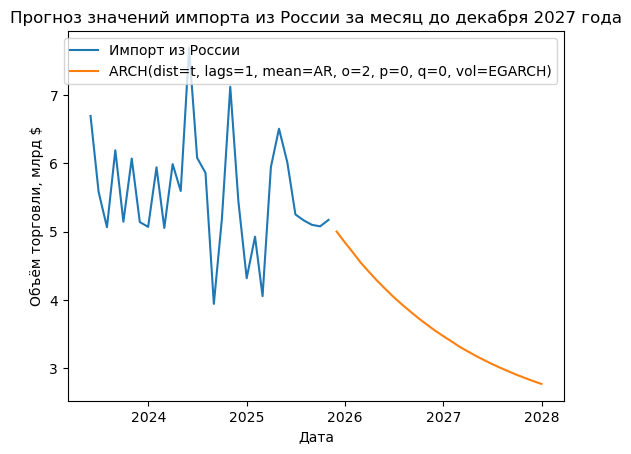

In [89]:
y_pred_g_rustoind = forecaster_g1.fit_predict(y=compare_fixed['rustoind'], fh=fh)
plt.plot(compare_fixed['rustoind'].tail(30), label='Импорт из России')
plt.plot(y_pred_g_rustoind, label='ARCH(dist=t, lags=1, mean=AR, o=2, p=0, q=0, vol=EGARCH)')
plt.xlabel('Дата')
plt.ylabel('Объём торговли, млрд $')
plt.title('Прогноз значений импорта из России за месяц до декабря 2027 года')
plt.legend()
plt.show()

In [80]:
y_pred_g_rustoind

2025-11-30    5.001543
2025-12-31    4.840235
2026-01-31    4.687694
2026-02-28    4.543444
2026-03-31    4.407033
2026-04-30    4.278035
2026-05-31    4.156048
2026-06-30    4.040691
2026-07-31    3.931603
2026-08-31    3.828444
2026-09-30    3.730892
2026-10-31    3.638641
2026-11-30    3.551403
2026-12-31    3.468907
2027-01-31    3.390894
2027-02-28    3.317121
2027-03-31    3.247358
2027-04-30    3.181385
2027-05-31    3.118999
2027-06-30    3.060003
2027-07-31    3.004213
2027-08-31    2.951455
2027-09-30    2.901564
2027-10-31    2.854385
2027-11-30    2.809770
2027-12-31    2.767580
Freq: ME, Name: rustoind, dtype: float64

In [90]:
compare.tail(45)

,rustoind,indtorus,rustoind_sma12,indtorus_sma12,indtorus_sma24,rustoind_sma24
date,,,,,,
2022-02-01,0.830843,0.325009,0.799124,0.287317,0.250950,0.634908
2022-03-01,1.328906,0.079093,0.858468,0.271511,0.246422,0.657690
2022-04-01,2.330251,0.096362,0.995054,0.259956,0.246495,0.739879
2022-05-01,2.702677,0.148681,1.162468,0.254347,0.245971,0.841290
2022-06-01,4.233832,0.190542,1.464335,0.249449,0.246373,1.000499
2022-07-01,4.229788,0.278697,1.763627,0.245935,0.247989,1.149932
2022-08-01,4.322248,0.278382,2.064928,0.244775,0.250542,1.312514
2022-09-01,4.958569,0.297546,2.384056,0.245856,0.252457,1.503162
2022-10-01,4.695741,0.280026,2.712253,0.246691,0.255267,1.679575
